In [1]:
import pandas as pd
import numpy as np
import random as rn
import matplotlib.pyplot as plt

In [2]:
num_samples=10000

Defining a function to gather A, B, C, D, E to make a dataframe

In [3]:
def gather_data (A,B,C,D,E):
    """Gathers df columns"""
    df=pd.DataFrame([A,B,C,D,E])
    df.index=["A","B","C","D","E"]
    df=df.T
    return df

Making an empty dataframe and then locking values individually

In [ ]:
def value_loc_dataframe (c_a_t, c_a_o, c_b_o, c_d_t, c_e_t, c_e_o, c_t_o):
    nodes = ['A', 'B', 'C', 'D', 'E', 'Treatment', 'Outcome']

    df_effects_sizes = pd.DataFrame(columns=nodes, index=nodes, dtype=int).fillna(0)
    df_effects_sizes.loc['A', 'Treatment'] = c_a_t
    df_effects_sizes.loc['A', 'Outcome'] = c_a_o
    df_effects_sizes.loc['B', 'Outcome'] = c_b_o
    df_effects_sizes.loc['D', 'Treatment'] = c_d_t
    df_effects_sizes.loc['E', 'Treatment'] = c_e_t
    df_effects_sizes.loc['E', 'Outcome'] = c_e_o
    df_effects_sizes.loc['Treatment', 'Outcome'] = c_t_o

    return df_effects_sizes

Making an empty dataframe and then adding 1s and 0s (this is to make a dataframe for edges)

In [5]:
def edges_dataframe (a_t, a_o, b_o, d_t, e_t, e_o, t_o):
    nodes = ['A', 'B', 'C', 'D', 'E', 'Treatment', 'Outcome']

    df_edges = pd.DataFrame(columns=nodes, index=nodes, dtype=int).fillna(0)
    df_edges.loc['A', 'Treatment'] = a_t
    df_edges.loc['A', 'Outcome'] = a_o
    df_edges.loc['B', 'Outcome'] = b_o
    df_edges.loc['D', 'Treatment'] = d_t
    df_edges.loc['E', 'Treatment'] = e_t
    df_edges.loc['E', 'Outcome'] = e_o
    df_edges.loc['Treatment', 'Outcome'] = t_o

    return df_edges

Defining a function to asign treatment values to the dataframe (either 0 (No) or 1 (Yes))

In [6]:
def treatment_causal_effects (df, c_a_t, c_e_t, c_d_t):
    """Calculates treatment values (0 or 1)"""
    
    np.random.seed(42)
    noise_t = np.random.normal(0, 0.1, num_samples)
    t = np.sum([noise_t] + [c_a_t*df["A"]] + [c_e_t*df["E"]] + [c_d_t*df["D"]], axis=0)

    t_bin = np.array([convert_to_binary(x) for x in t]).flatten()

    return t_bin

Defining a function to calculate outcome values

In [7]:
def outcome_causal_effects (df, c_t_o, c_a_o, c_e_o, c_b_o):
    """Calculates outcome values"""

    np.random.seed(42)
    noise_out = np.random.normal(0, 0.1, num_samples)
    out = np.sum([noise_out] + [c_t_o*df["Treatment"]] + [c_a_o*df["A"]] + [c_e_o*df["E"]] + [c_b_o*df["B"]*df["Treatment"]], axis=0)

    return out

In [8]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def convert_to_binary(x, stochastic=True):
    p = sigmoid(x)
    if stochastic:
        return np.random.choice([0, 1], 1, p=[1 - p, p])
    else:
        return int(p > 0.5)

Defining a function to make the subplots

In [9]:
def make_subplot(df, suptitle,file_path):
    """Makes a subplot of all the columns"""
    n_rows = 2
    n_cols = 4
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 8))
    for i, a in enumerate(df.columns):

        # # To fill each column in turn: col = l // n_rows
        # To fill each row in turn: row = l % n_rows
        row = i // n_cols
        col = i % n_cols

        #print(row, col)

        axs[row,col].hist(df[a])
        axs[row,col].set_title(f"{[a]}")

    # Make remaining subplots blank:
    i += 1
    while i < n_rows*n_cols:
    # Make sure this matches definition of row and col above.
        row = i // n_cols
        col = i % n_cols
        axs[row, col].set_visible(False)
        i += 1

    plt.suptitle(suptitle)
    plt.savefig(file_path)
    plt.show()

!!! Remember to update number everytime !!!

In [ ]:
savename = "new_continous_test_data_3"
#define the name of the dataset you want to access

Making a reference dataframe

In [ ]:
np.random.seed(42)

ref_a = np.random.normal(-0.25, 1, num_samples)
ref_b = np.random.normal(0.20, 1, num_samples)
ref_c = np.random.normal(-0.69, 1, num_samples)
ref_d = np.random.binomial(1,0.73,num_samples)
ref_e = np.random.normal(0.90, 1, num_samples)

#these values run the same for all the various datasets btw

df_ref=pd.DataFrame([ref_a,ref_b,ref_c,ref_d,ref_e],index=["ref_a","ref_b","ref_c","ref_d","ref_e"])
df_ref=df_ref.T

df_ref_final=gather_data(ref_a,ref_b,ref_c,ref_d,ref_e)

c_a_t=1.60 # A and treatment
c_e_t=1.40 # E and treatment
c_d_t=1.80 # D and treatment

df_ref_final["Treatment"]=treatment_causal_effects(df_ref_final,c_a_t, c_e_t, c_d_t)

c_t_o=3 # Treatment and outcome
c_a_o=1.60 # A and outcome
c_e_o=1.40 # E and outcome
c_b_o=1.50 # B and outcome

df_ref_final["Outcome"]=outcome_causal_effects(df_ref_final,c_t_o, c_a_o, c_e_o, c_b_o)

df_ref_final.to_csv(f"reference_{savename}.csv", index=False)

Making a dataframe which has all the causal relationships

In [ ]:
df_effects=value_loc_dataframe (c_a_t, c_a_o, c_b_o, c_d_t, c_e_t, c_e_o, c_t_o)

import os
directory = "Causal effects" #name of folder
file_name= f"ce_reference_{savename}.csv" #name of how you want to save the file
file_path = os.path.join(directory, file_name) #telling the path you want it to follow
df_effects.to_csv(file_path, index=True)

df_effects.to_csv(f"ce_reference_{savename}.csv", index=True)

Making a dataframe which has 0 and 1 (1 for everytime there is an edge)

In [63]:
df_edges=edges_dataframe (1, 1, 1, 1, 1, 1, 1)

import os
directory = "Edges"
file_name= f"edges_reference_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_edges.to_csv(file_path, index=True)

df_edges.to_csv(f"edges_reference_{savename}.csv", index=True)

Making histogram subplots for this data

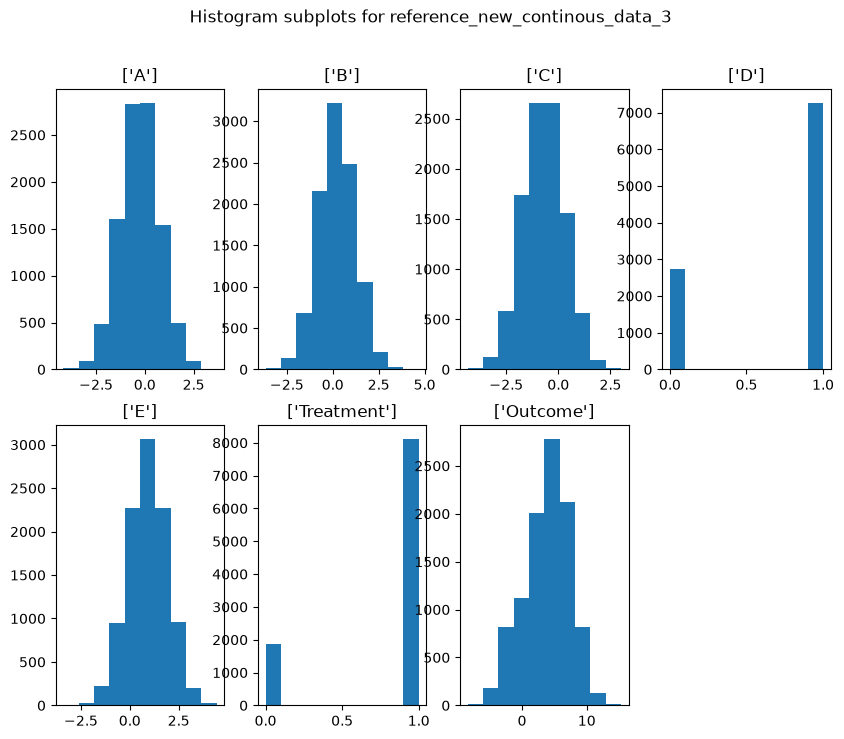

In [12]:
n_rows = 2
n_cols = 4
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i, a in enumerate(df_ref_final.columns):

    # # To fill each column in turn: col = i // n_rows
    # To fill each row in turn: row = i % n_rows
    row = i // n_cols
    col = i % n_cols

    #print(row, col)

    axs[row,col].hist(df_ref_final[a])
    axs[row,col].set_title(f"{[a]}")

# Make remaining subplots blank:
i += 1
while i < n_rows*n_cols:
    # Make sure this matches definition of row and col above.
    row = i // n_cols
    col = i % n_cols
    axs[row, col].set_visible(False)
    i += 1

plt.suptitle("Histogram subplots for reference_new_continous_data_3")

import os
directory ="Subplots"
file_name=f"reference_{savename}.png"
file_path = os.path.join(directory, file_name)
plt.savefig(file_path)
plt.show()


Continous Data with D using arrival to scan time

In [15]:
A = ref_a
B = ref_b
C = ref_c

df_ATST=pd.read_csv("arrival_to_scan_time.csv")
klm=df_ATST["bin_edge"]
np.random.seed(42)
D = np.random.choice(klm,10000,p=df_ATST["height"])

E = ref_e

df=gather_data(A,B,C,D,E)

c_a_t=1.60
c_e_t=1.40
c_d_t=1.80

df["Treatment"]=treatment_causal_effects(df, c_a_t, c_e_t, c_d_t)

c_t_o=3.00
c_a_o=1.60
c_e_o=1.40
c_b_o=1.50

df["Outcome"]=outcome_causal_effects(df, c_t_o, c_a_o, c_e_o, c_b_o)

df

,A,B,C,D,E,Treatment,Outcome
0,0.246714,-0.478495,-0.341714,15.0,1.598605,1,4.964719
1,-0.388264,-0.105499,-0.406676,120.0,1.165029,1,3.837742
2,0.397689,-0.397381,-1.626520,30.0,-1.041670,1,1.646661
3,1.273030,0.310418,-0.110416,15.0,0.496802,1,6.350301
4,-0.484153,1.397179,-2.180083,0.0,0.763837,1,5.367078
...,...,...,...,...,...,...,...
9995,1.051102,0.587827,-1.267288,60.0,0.501363,1,6.395522
9996,-2.248345,1.577367,0.754604,75.0,1.571973,1,3.769626
9997,-0.955317,0.578354,-1.191367,120.0,2.617194,1,5.932564
9998,0.245766,1.913530,-2.582357,15.0,1.733103,1,8.739440


Saving this dataframe

In [ ]:
import os
directory = "Datasets"
file_name= f"ATST_{savename}.csv"
file_path = os.path.join(directory, file_name)
df.to_csv(file_path, index=False)
#ATST is arrival to scan time

Making a dataframe which has all the causal relationships

In [22]:
df_effects=value_loc_dataframe (c_a_t, c_a_o, c_b_o, c_d_t, c_e_t, c_e_o, c_t_o)

directory = "Causal effects"
file_name= f"ce_ATST_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_effects.to_csv(file_path, index=True)

Making a dataframe which has 0 and 1 (1 for everytime there is an edge)


In [23]:
df_edges=edges_dataframe (1, 1, 1, 1, 1, 1, 1)

import os
directory = "Edges"
file_name= f"edges_ATST_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_edges.to_csv(file_path, index=True)

Making histogram subplots for this data

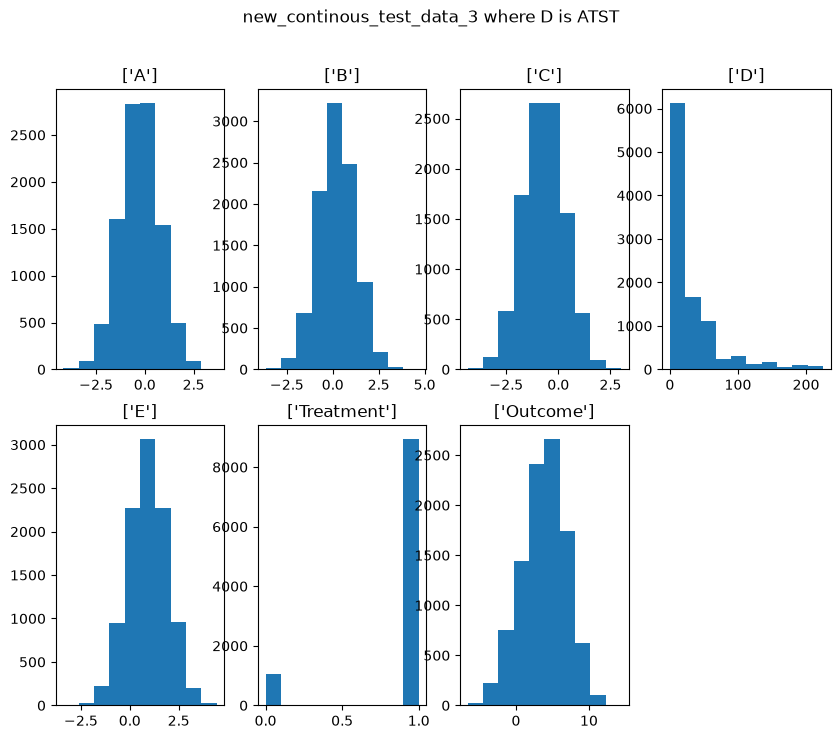

In [92]:
directory = "Subplots"
file_name=f"{savename}_D_ATST.png"
file_path = os.path.join(directory, file_name)

make_subplot(df,suptitle=f"{savename} where D is ATST",file_path=file_path)

Continous Data with D as prior disability

In [35]:
A = ref_a
B = ref_b
C = ref_c

df_DIS=pd.read_csv("prior_disability.csv")
klm=df_DIS["prior_disability"]
np.random.seed(42)
D=np.random.choice(klm,10000,p=df_DIS["count"])

E = ref_e

df=gather_data(A,B,C,D,E)

c_a_t=1.60
c_e_t=1.40
c_d_t=1.80

df["Treatment"]=treatment_causal_effects(df, c_a_t, c_e_t, c_d_t)

c_t_o=3.00
c_a_o=1.60
c_e_o=1.40
c_b_o=1.50

df["Outcome"]=outcome_causal_effects(df, c_t_o, c_a_o, c_e_o, c_b_o)

df

,A,B,C,D,E,Treatment,Outcome
0,0.246714,-0.478495,-0.341714,0.0,1.598605,1,4.964719
1,-0.388264,-0.105499,-0.406676,4.0,1.165029,1,3.837742
2,0.397689,-0.397381,-1.626520,3.0,-1.041670,1,1.646661
3,1.273030,0.310418,-0.110416,1.0,0.496802,1,6.350301
4,-0.484153,1.397179,-2.180083,0.0,0.763837,1,5.367078
...,...,...,...,...,...,...,...
9995,1.051102,0.587827,-1.267288,2.0,0.501363,1,6.395522
9996,-2.248345,1.577367,0.754604,2.0,1.571973,1,3.769626
9997,-0.955317,0.578354,-1.191367,4.0,2.617194,1,5.932564
9998,0.245766,1.913530,-2.582357,0.0,1.733103,1,8.739440


Saving this dataframe

In [25]:
import os
directory = "Datasets"
file_name= f"DIS_{savename}.csv"
file_path = os.path.join(directory, file_name)
#df.to_csv(file_path, index=False)
#DIS is known prior disability

Making a dataframe which has all the causal relationships

In [36]:
df_effects=value_loc_dataframe (c_a_t, c_a_o, c_b_o, c_d_t, c_e_t, c_e_o, c_t_o)

directory = "Causal effects"
file_name= f"ce_DIS_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_effects.to_csv(file_path, index=True)

Making a dataframe which has 0 and 1 (1 for everytime there is an edge)

In [37]:
df_edges=edges_dataframe (1, 1, 1, 1, 1, 1, 1)

import os
directory = "Edges"
file_name= f"edges_DIS_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_edges.to_csv(file_path, index=True)

Making histogram subplots for this data

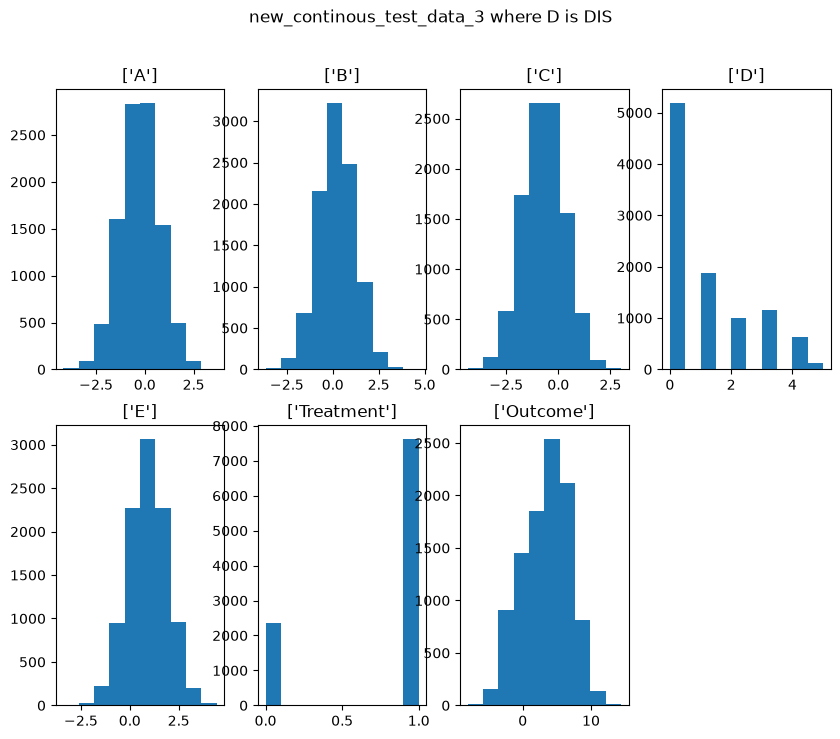

In [96]:
directory = "Subplots"
file_name=f"{savename}_D_DIS.png"
file_path = os.path.join(directory, file_name)

make_subplot(df,suptitle=f"{savename} where D is DIS",file_path=file_path)

Continous Data with D as stroke severity

In [38]:
A = ref_a
B = ref_b
C = ref_c

df_SS=pd.read_csv("stroke_severity.csv")
klm=df_SS["stroke_severity"]
np.random.seed(42)
D=np.random.choice(klm,10000,p=df_SS["count"])

E = ref_e

df=gather_data(A,B,C,D,E)

c_a_t=1.60
c_e_t=1.40
c_d_t=1.80

df["Treatment"]=treatment_causal_effects(df, c_a_t, c_e_t, c_d_t)

c_t_o=3.00
c_a_o=1.60
c_e_o=1.40
c_b_o=1.50

df["Outcome"]=outcome_causal_effects(df, c_t_o, c_a_o, c_e_o, c_b_o)

df

,A,B,C,D,E,Treatment,Outcome
0,0.246714,-0.478495,-0.341714,5.0,1.598605,1,4.964719
1,-0.388264,-0.105499,-0.406676,25.0,1.165029,1,3.837742
2,0.397689,-0.397381,-1.626520,13.0,-1.041670,1,1.646661
3,1.273030,0.310418,-0.110416,9.0,0.496802,1,6.350301
4,-0.484153,1.397179,-2.180083,3.0,0.763837,1,5.367078
...,...,...,...,...,...,...,...
9995,1.051102,0.587827,-1.267288,16.0,0.501363,1,6.395522
9996,-2.248345,1.577367,0.754604,21.0,1.571973,1,3.769626
9997,-0.955317,0.578354,-1.191367,25.0,2.617194,1,5.932564
9998,0.245766,1.913530,-2.582357,6.0,1.733103,1,8.739440


Saving this dataframe

In [98]:
import os
directory = "Datasets"
file_name= f"SS_{savename}.csv"
file_path = os.path.join(directory, file_name)
df.to_csv(file_path, index=False)
#SS is stroke severity

Making a dataframe which has all the causal relationships

In [39]:
df_effects=value_loc_dataframe (c_a_t, c_a_o, c_b_o, c_d_t, c_e_t, c_e_o, c_t_o)

directory = "Causal effects"
file_name= f"ce_SS_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_effects.to_csv(file_path, index=True)

Making a dataframe which has 0 and 1 (1 for everytime there is an edge)

In [40]:
df_edges=edges_dataframe (1, 1, 1, 1, 1, 1, 1)

import os
directory = "Edges"
file_name= f"edges_SS_{savename}.csv"
file_path = os.path.join(directory, file_name)
df_edges.to_csv(file_path, index=True)

Making histogram subplots for this data

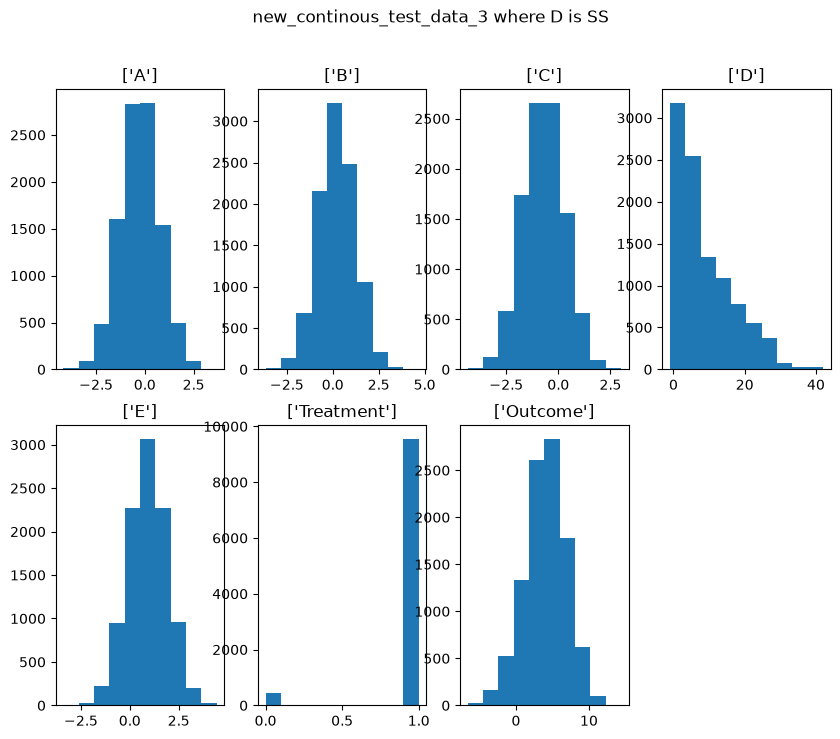

In [100]:
directory = "Subplots"
file_name=f"{savename}_D_SS.png"
file_path = os.path.join(directory, file_name)

make_subplot(df,suptitle=f"{savename} where D is SS",file_path=file_path)